In [1]:
pip list


Package                      Version
---------------------------- -----------
absl-py                      2.1.0
asttokens                    2.0.5
astunparse                   1.6.3
cachetools                   5.5.0
certifi                      2024.12.14
charset-normalizer           3.4.1
colorama                     0.4.6
comm                         0.2.1
contourpy                    1.3.1
cycler                       0.12.1
debugpy                      1.8.11
decorator                    5.1.1
efficientnet                 1.0.0
exceptiongroup               1.2.0
executing                    0.8.3
flatbuffers                  24.12.23
fonttools                    4.55.3
gast                         0.6.0
google-auth                  2.37.0
google-auth-oauthlib         1.2.1
google-pasta                 0.2.0
grpcio                       1.69.0
h5py                         3.12.1
idna                         3.10
image-classifiers            1.0.0
imageio                      2.36.

In [1]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"
import cv2
from PIL import Image
from patchify import patchify
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import random

In [2]:
minmaxscalar = MinMaxScaler()

In [ ]:
dataset_root_folder = r"D:/Shubham/Major Project/major/"

In [ ]:

dataset_name = 'Folder'

In [5]:
for path, subdirs, files in os.walk(os.path.join(dataset_root_folder, dataset_name)):
  dir_name = path.split(os.path.sep)[-1]
  #print(dir_name)
  if dir_name == 'images': #masks
    images = os.listdir(path)
    #print(path)
    #print(images)
    for i, image_name in enumerate(images):
      if(image_name.endswith('.jpg')): #.png
        #print(image_name)

        a = True
     


In [6]:

image_patch_size = 256

In [7]:
image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/images/image_01.jpg',1)

In [8]:
image.shape
     

(6715, 4297, 3)

In [9]:
image_patches = patchify(image, (image_patch_size, image_patch_size, 3), step = image_patch_size)

In [10]:
print(image_patches.shape)

(26, 16, 1, 256, 256, 3)


In [11]:
image_x = image_patches[0,0,:,:]

#MinMaxScalar
image_y = minmaxscalar.fit_transform(image_x.reshape(-1, image_x.shape[-1])).reshape(image_x.shape)

In [12]:

image_y[0].shape
     

(256, 256, 3)

In [13]:
print(type(image))

<class 'numpy.ndarray'>


In [14]:
type(Image.fromarray(image))

PIL.Image.Image

In [15]:
image.shape

(6715, 4297, 3)

In [16]:

(image.shape[0]//image_patch_size)*image_patch_size
(image.shape[1]//image_patch_size)*image_patch_size
     

4096

In [17]:

image_dataset = []
mask_dataset = []

for image_type in ['images' , 'masks']:
  if image_type == 'images':
    image_extension = 'jpg'
  elif image_type == 'masks':
     image_extension = 'png'
  for image_id in range(1,9):
      image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/{image_type}/image_0{image_id}.{image_extension}',1)
      if image is not None:
        if image_type == 'masks':
          image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #print(image.shape)
        size_x = (image.shape[1]//image_patch_size)*image_patch_size
        size_y = (image.shape[0]//image_patch_size)*image_patch_size
        #print("{} --- {} - {}".format(image.shape, size_x, size_y))
        image = Image.fromarray(image)
        image = image.crop((0,0, size_x, size_y))
        #print("({},  {})".format(image.size[0],image.size[1]))
        image = np.array(image)
        patched_images = patchify(image, (image_patch_size, image_patch_size, 3), step=image_patch_size)
        #print(len(patched_images))
        for i in range(patched_images.shape[0]):
          for j in range(patched_images.shape[1]):
            if image_type == 'images':
              individual_patched_image = patched_images[i,j,:,:]
              #print(individual_patched_image.shape)
              individual_patched_image = minmaxscalar.fit_transform(individual_patched_image.reshape(-1, individual_patched_image.shape[-1])).reshape(individual_patched_image.shape)
              individual_patched_image = individual_patched_image[0]
              #print(individual_patched_image.shape)
              image_dataset.append(individual_patched_image)
            elif image_type == 'masks':
              individual_patched_mask = patched_images[i,j,:,:]
              individual_patched_mask = individual_patched_mask[0]
              mask_dataset.append(individual_patched_mask)

In [18]:
print(len(image_dataset))
print(len(mask_dataset))

3182
3182


In [19]:

image_dataset = np.array(image_dataset)
mask_dataset = np.array(mask_dataset)
     

In [20]:

print(len(image_dataset))
print(len(mask_dataset))

3182
3182


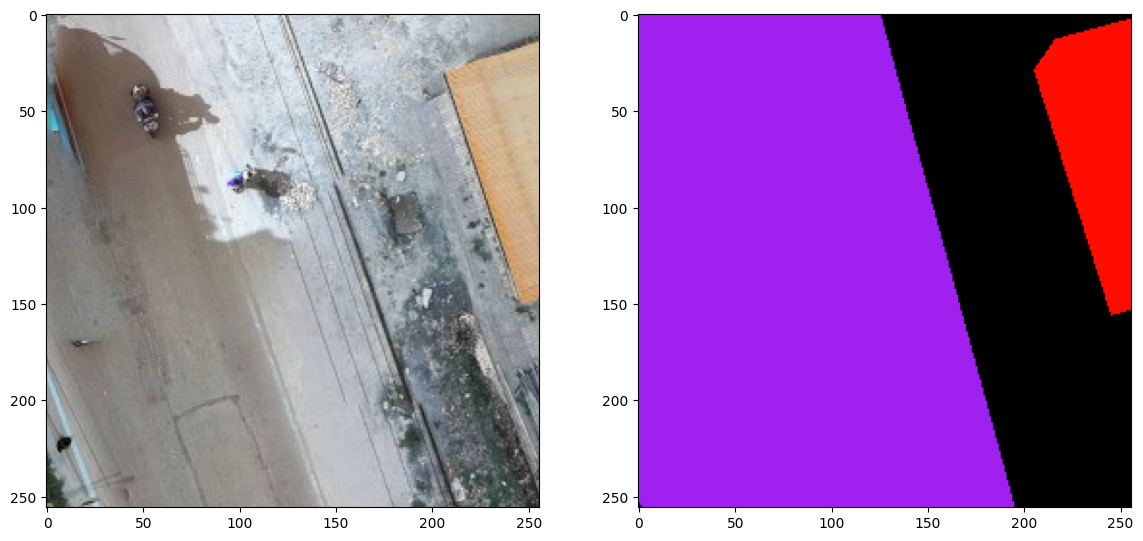

In [21]:

random_image_id = random.randint(0, len(image_dataset)-1)

plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.imshow(image_dataset[random_image_id])
plt.subplot(1,2,2)
plt.imshow(mask_dataset[random_image_id])

     

In [22]:
class_building = '#FF0D00'
class_building = class_building.lstrip('#')
class_building = np.array(tuple(int(class_building[i:i+2], 16) for i in (0, 2, 4)))
print(class_building)

class_land = '#FFA200'
class_land = class_land.lstrip('#')
class_land = np.array(tuple(int(class_land[i:i+2], 16) for i in (0, 2, 4)))
print(class_land)

class_road = '#A020F0'
class_road = class_road.lstrip('#')
class_road = np.array(tuple(int(class_road[i:i+2], 16) for i in (0, 2, 4)))
print(class_road)

class_vegetation = '#126B00'
class_vegetation = class_vegetation.lstrip('#')
class_vegetation = np.array(tuple(int(class_vegetation[i:i+2], 16) for i in (0, 2, 4)))
print(class_vegetation)

class_water = '#006EFF'
class_water = class_water.lstrip('#')
class_water = np.array(tuple(int(class_water[i:i+2], 16) for i in (0, 2, 4)))
print(class_water)

[255  13   0]
[255 162   0]
[160  32 240]
[ 18 107   0]
[  0 110 255]


In [23]:
print(mask_dataset.shape)

(3182, 256, 256, 3)


In [24]:

individual_patched_mask.shape

(256, 256, 3)

In [25]:
label = individual_patched_mask

In [26]:

def rgb_to_label(label):
  label_segment = np.zeros(label.shape, dtype=np.uint8)
  label_segment[np.all(label == class_land, axis=-1)] = 0
  label_segment[np.all(label == class_building, axis=-1)] = 1
  label_segment[np.all(label == class_road, axis=-1)] = 2
  label_segment[np.all(label == class_vegetation, axis=-1)] = 3
  label_segment[np.all(label == class_water, axis=-1)] = 4
  #print(label_segment)
  label_segment = label_segment[:,:,0]
  #print(label_segment)
  return label_segment
     

In [45]:
labels = []
for i in range(mask_dataset.shape[0]):
  label = rgb_to_label(mask_dataset[i])
  labels.append(label)

In [46]:
len(labels)

3182

In [47]:

labels = np.array(labels)
     

In [48]:

labels[1]

array([[0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [49]:

labels = np.expand_dims(labels, axis=3)

In [50]:
labels[0]
     

array([[[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       ...,

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]]], dtype=uint8)

In [51]:

np.unique(labels)

array([0, 1, 2, 3, 4], dtype=uint8)

In [52]:
print("Total unique values based on masks: ",format(np.unique(labels)))

Total unique values based on masks:  [0 1 2 3 4]


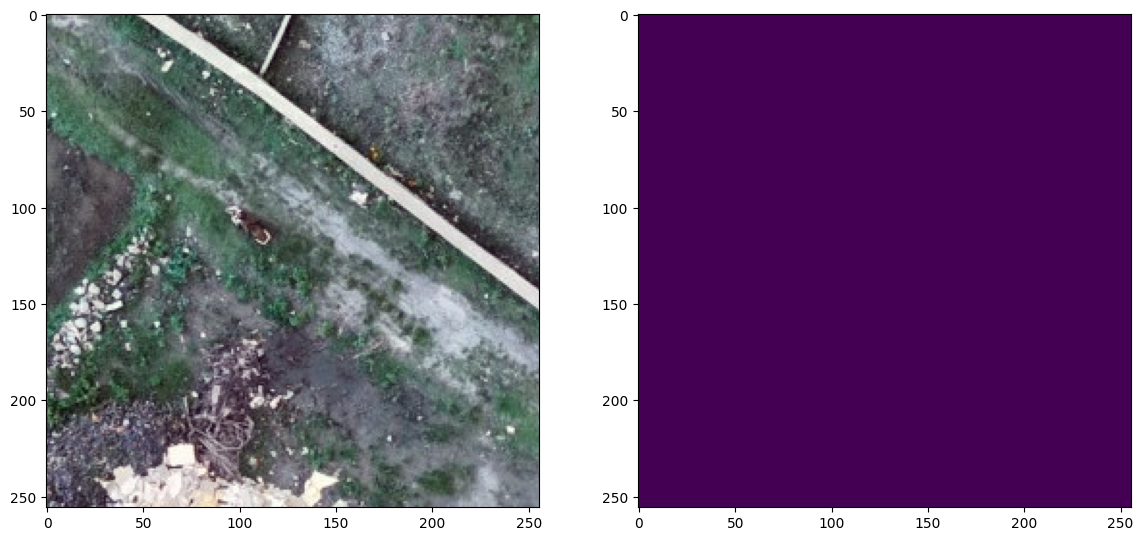

In [53]:
random_image_id = random.randint(0, len(image_dataset)-1)

plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.imshow(image_dataset[random_image_id])
plt.subplot(1,2,2)
#plt.imshow(mask_dataset[random_image_id])
plt.imshow(mask_dataset[random_image_id])
plt.imshow(labels[random_image_id][:,:,0])

In [54]:
labels[0][:,:,0]


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [55]:
total_classes = len(np.unique(labels))

In [56]:
total_classes

5

In [57]:
from tensorflow.keras.utils import to_categorical

In [59]:
labels_categorical_dataset = to_categorical(labels, num_classes = total_classes)

In [60]:
labels_categorical_dataset.shape

(3182, 256, 256, 5)

In [61]:

master_training_dataset = image_dataset

In [62]:

from sklearn.model_selection import train_test_split

In [63]:
x_train, x_test, y_train, y_test = train_test_split(master_training_dataset, labels_categorical_dataset, test_size=0.15, random_state = 100)
     

In [64]:

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2704, 256, 256, 3)
(478, 256, 256, 3)
(2704, 256, 256, 5)
(478, 256, 256, 5)


In [65]:
image_height = x_train.shape[1]
image_width = x_train.shape[2]
image_channels = x_train.shape[3]
total_classes = y_train.shape[3]

In [66]:

print(image_height)
print(image_width)
print(image_channels)
print(total_classes)

256
256
3
5


In [67]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda


In [68]:
from keras import backend as K

In [69]:
# pip install segmentation-models


In [70]:

import tensorflow.keras.backend as K
import segmentation_models as sm
import tensorflow as tf
     

Segmentation Models: using `tf.keras` framework.


In [71]:
def jaccard_coef(y_true, y_pred):
    y_true_flatten = K.flatten(y_true)
    y_pred_flatten = K.flatten(y_pred)
    intersection = K.sum(y_true_flatten * y_pred_flatten)
    final_coef_value = (intersection + 1.0) / (K.sum(y_true_flatten) + K.sum(y_pred_flatten) - intersection + 0.1)
    return final_coef_value

In [72]:


from ctypes import c_int8
def multi_unet_model(n_classes = 5, image_height = 256, image_width = 256, image_channels = 1):

  inputs = Input((image_height, image_width, image_channels))

  source_input = inputs

  c1 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(source_input)
  c1 = Dropout(0.2)(c1)
  c1 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c1)
  p1 = MaxPooling2D((2,2))(c1)

  c2 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p1)
  c2= Dropout(0.2)(c2)
  c2 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c2)
  p2 = MaxPooling2D((2,2))(c2)

  c3 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p2)
  c3= Dropout(0.2)(c3)
  c3 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c3)
  p3 = MaxPooling2D((2,2))(c3)

  c4 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p3)
  c4= Dropout(0.2)(c4)
  c4 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c4)
  p4 = MaxPooling2D((2,2))(c4)

  c5 = Conv2D(256, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p4)
  c5= Dropout(0.2)(c5)
  c5 = Conv2D(256, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c5)

  u6 = Conv2DTranspose(128, (2,2), strides = (2,2), padding='same')(c5)
  u6 = concatenate([u6, c4])

  c6 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u6)
  c6 = Dropout(0.2)(c6)
  c6 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c6)

  u7 = Conv2DTranspose(64, (2,2), strides = (2,2), padding='same')(c6)
  u7 = concatenate([u7, c3])

  c7 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u7)
  c7 = Dropout(0.2)(c7)
  c7 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c7)

  u8 = Conv2DTranspose(32, (2,2), strides = (2,2), padding='same')(c7)
  u8 = concatenate([u8, c2])

  c8 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u8)
  c8 = Dropout(0.2)(c8)
  c8 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c8)

  u9 = Conv2DTranspose(16, (2,2), strides = (2,2), padding='same')(c8)
  u9 = concatenate([u9, c1], axis=3)

  c9 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u9)
  c9 = Dropout(0.2)(c9)
  c9 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c9)

  outputs = Conv2D(n_classes, (1,1), activation = 'softmax')(c9)

  model = Model(inputs = [inputs], outputs = [outputs])

  return model


In [73]:
def get_deep_learning_model():
  return multi_unet_model(n_classes = total_classes, image_height = image_height, image_width = image_width, image_channels = image_channels)
     

In [74]:
model = get_deep_learning_model()

In [75]:
weights = tf.constant([0.166, 0.166, 0.166, 0.166, 0.166])  # 5 classes
     

In [76]:

dice_loss = sm.losses.DiceLoss(class_weights=weights)
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)

In [77]:

tf.keras.backend.clear_session()

In [78]:
model.compile(optimizer = 'adam', loss = total_loss, metrics = ['accuracy', jaccard_coef])

In [79]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 16)         448       ['input_1[0][0]']             
                                                                                                  
 dropout (Dropout)           (None, 256, 256, 16)         0         ['conv2d[0][0]']              
                                                                                                  
 conv2d_1 (Conv2D)           (None, 256, 256, 16)         2320      ['dropout[0][0]']             
                                                                                              

 conv2d_transpose_3 (Conv2D  (None, 256, 256, 16)         2064      ['conv2d_15[0][0]']           
 Transpose)                                                                                       
                                                                                                  
 concatenate_3 (Concatenate  (None, 256, 256, 32)         0         ['conv2d_transpose_3[0][0]',  
 )                                                                   'conv2d_1[0][0]']            
                                                                                                  
 conv2d_16 (Conv2D)          (None, 256, 256, 16)         4624      ['concatenate_3[0][0]']       
                                                                                                  
 dropout_8 (Dropout)         (None, 256, 256, 16)         0         ['conv2d_16[0][0]']           
                                                                                                  
 conv2d_17

In [80]:

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (2704, 256, 256, 3)
y_train shape: (2704, 256, 256, 5)
x_test shape: (478, 256, 256, 3)
y_test shape: (478, 256, 256, 5)


In [81]:
# import tensorflow as tf
# gpus = tf.config.experimental.list_physical_devices('GPU')
# if gpus:
#     try:
#         # Set memory growth to avoid consuming all GPU memory
#         for gpu in gpus:
#             tf.config.experimental.set_memory_growth(gpu, True)
#     except RuntimeError as e:
#         print(e)


In [82]:
# x_train = x_train.astype('float32')
# y_train = y_train.astype('float32')
# x_test = x_test.astype('float32')
# y_test = y_test.astype('float32')

In [83]:
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt

# Define a callback to save the model at the end of each epoch
class SaveModelEveryTenEpochs(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:  # Save every 10th epoch
            filename = f'model_epoch_{epoch + 1:02d}.h5'
            self.model.save(filename)
            print(f'\nModel saved to {filename}')

In [84]:
model_history = model.fit(
    x_train, y_train,
    batch_size=16,
    verbose=1,
    epochs=50,  # Adjust epochs as needed
    validation_data=(x_test, y_test),
    shuffle=False,
    callbacks=[SaveModelEveryTenEpochs()]
)

Epoch 1/50


169/169 [==============================] - 565s 3s/step - loss: 0.9902 - accuracy: 0.5252 - jaccard_coef: 0.2415 - val_loss: 0.9778 - val_accuracy: 0.5744 - val_jaccard_coef: 0.2859
Epoch 2/50
169/169 [==============================] - 552s 3s/step - loss: 0.9739 - accuracy: 0.5988 - jaccard_coef: 0.3156 - val_loss: 0.9687 - val_accuracy: 0.5943 - val_jaccard_coef: 0.3307
Epoch 3/50
169/169 [==============================] - 540s 3s/step - loss: 0.9673 - accuracy: 0.6191 - jaccard_coef: 0.3484 - val_loss: 0.9631 - val_accuracy: 0.6211 - val_jaccard_coef: 0.3673
Epoch 4/50
169/169 [==============================] - 544s 3s/step - loss: 0.9616 - accuracy: 0.6480 - jaccard_coef: 0.3784 - val_loss: 0.9586 - val_accuracy: 0.6541 - val_jaccard_coef: 0.3912
Epoch 5/50
169/169 [==============================] - 542s 3s/step - loss: 0.9581 - accuracy: 0.6644 - jaccard_coef: 0.3960 - val_loss: 0.9561 - val_accuracy: 0.6602 - val_jaccard_coef: 0.3999
Epoch 6/50
169/169 [=============

C:\Users\aryab\anaconda3\envs\realprj\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 11/50
169/169 [==============================] - 557s 3s/step - loss: 0.9448 - accuracy: 0.7048 - jaccard_coef: 0.4490 - val_loss: 0.9435 - val_accuracy: 0.6929 - val_jaccard_coef: 0.4379
Epoch 12/50
169/169 [==============================] - 538s 3s/step - loss: 0.9417 - accuracy: 0.7113 - jaccard_coef: 0.4577 - val_loss: 0.9418 - val_accuracy: 0.7009 - val_jaccard_coef: 0.4535
Epoch 13/50
169/169 [==============================] - 537s 3s/step - loss: 0.9379 - accuracy: 0.7210 - jaccard_coef: 0.4696 - val_loss: 0.9408 - val_accuracy: 0.7025 - val_jaccard_coef: 0.4557
Epoch 14/50
169/169 [==============================] - 537s 3s/step - loss: 0.9373 - accuracy: 0.7246 - jaccard_coef: 0.4739 - val_loss: 0.9411 - val_accuracy: 0.7148 - val_jaccard_coef: 0.4646
Epoch 15/50
169/169 [==============================] - 536s 3s/step - loss: 0.9360 - accuracy: 0.7285 - jaccard_coef: 0.4792 - val_loss: 0.9436 - val_accuracy: 0.6966 - val_jaccard_coef: 0.4559
Epoch 16/50
169/169 [=========

In [85]:
# model.compile(optimizer = 'adam', loss = total_loss, metrics = ['accuracy', jaccard_coef])

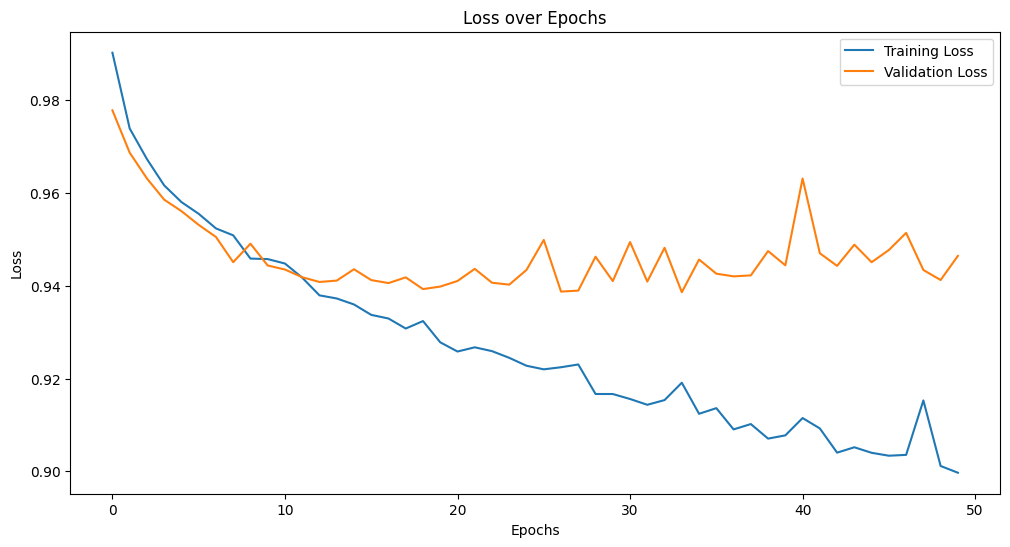

In [86]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(model_history.history['loss'], label='Training Loss')
plt.plot(model_history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

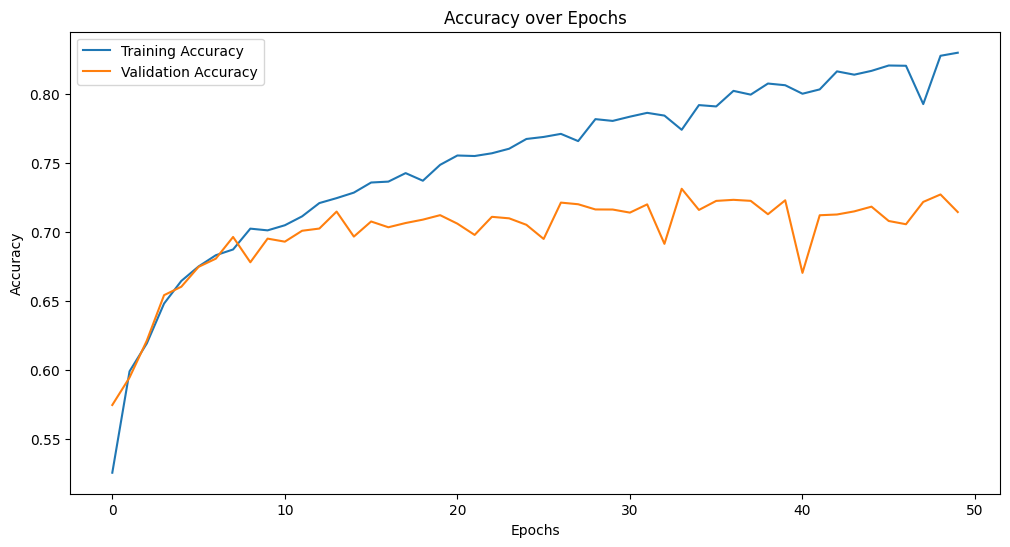

In [87]:
# Plot training and validation accuracy (if applicable)
if 'accuracy' in model_history.history:
    plt.figure(figsize=(12, 6))
    plt.plot(model_history.history['accuracy'], label='Training Accuracy')
    plt.plot(model_history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
# Save the model in SavedModel format
model.save("land_covers2.h5")


In [ ]:

history_a=model_history

In [ ]:

history_a.history

In [ ]:
import keras
from IPython.display import clear_output

%matplotlib inline
     

In [ ]:

loss = history_a.history['loss']
val_loss = history_a.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label="Training Loss")
plt.plot(epochs, val_loss, 'r', label="Validation Loss")
plt.title("Training Vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
     

In [ ]:

jaccard_coef = history_a.history['jaccard_coef']
val_jaccard_coef = history_a.history['val_jaccard_coef']

epochs = range(1, len(jaccard_coef) + 1)
plt.plot(epochs, jaccard_coef, 'y', label="Training IoU")
plt.plot(epochs, val_jaccard_coef, 'r', label="Validation IoU")
plt.title("Training Vs Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
     

In [ ]:
model_history.params

In [ ]:
y_pred = model.predict(x_test)

In [ ]:

len(y_pred)

In [ ]:
y_pred_argmax = np.argmax(y_pred, axis=3)

In [ ]:

len(y_pred_argmax)

In [ ]:
y_test_argmax = np.argmax(y_test, axis=3)

In [ ]:


test_image_number = random.randint(0, len(x_test))

test_image = x_test[test_image_number]
ground_truth_image = y_test_argmax[test_image_number]

test_image_input = np.expand_dims(test_image, 0)

prediction = model.predict(test_image_input)
predicted_image = np.argmax(prediction, axis=3)
predicted_image = predicted_image[0,:,:]

In [ ]:

plt.figure(figsize=(14,8))
plt.subplot(231)
plt.title("Original Image")
plt.imshow(test_image)
plt.subplot(232)
plt.title("Original Masked image")
plt.imshow(ground_truth_image)
plt.subplot(233)
plt.title("Predicted Image")
plt.imshow(predicted_image)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Load and preprocess the input image
img_path = "nepal_dataset/images/image_01.jpg"
img = image.load_img(img_path, target_size=(256, 256))  # Use the correct input size for your model
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  # Normalize if your model requires it

# Predict
y_pred = model.predict(img_array)

# Reshape or process the prediction if needed
# For example, if y_pred is a batch of 1 image, remove the batch dimension
pred_image = np.squeeze(y_pred)  # Remove batch dimension (shape: height, width, channels)

# Display the prediction as an image
plt.figure(figsize=(8, 8))
plt.imshow(pred_image, cmap="gray")  # Use 'gray' for grayscale, or remove cmap for RGB
plt.axis('off')
plt.title("Predicted Output")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_pred has shape (1, 256, 256, 5)
pred_image = np.squeeze(y_pred)  # Remove batch dimension -> (256, 256, 5)

# Take the argmax along the last axis to get the predicted class
pred_class_image = np.argmax(pred_image, axis=-1)  # Shape: (256, 256)

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(pred_class_image, cmap="gray")  # Display as grayscale
plt.axis('off')
plt.title("Predicted Class Output")
plt.show()
